# Hello World

In [1]:
print("hello python")

hello python


# Load dataset from azure ml data assets

In [2]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

# Initialize MLClient using your local workspace config
ml_client = MLClient.from_config(credential=DefaultAzureCredential())

Found the config file in: /config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


In [4]:
# Get the registered data asset metadata
data_asset = ml_client.data.get(name="iris", version="1")

# Extract the cloud or local path string
data_path = data_asset.path
data_path

'azureml://subscriptions/f68771b9-6725-4236-a5b5-f3988c05cc51/resourcegroups/onesinus231-rg/workspaces/ones-azure-ml/datastores/workspaceblobstore/paths/UI/2026-08-22_112611_UTC/iris.csv/'

In [5]:
import pandas as pd

# Load directly using the file path URI
df = pd.read_csv(data_path)

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.8.1) and child packages mlflow-skinny (3.5.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attem

In [6]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


# Build our first ML model using Python

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- 1. Prepare data ---
# (Assuming 'df' contains your loaded Azure data asset dataframe)

# Split features (X) and target label (y)
X = df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']]
y = df['variety']

# Convert text labels ('Setosa', etc.) into numbers (0, 1, 2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- 2. Train-Test Split ---
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- 3. Model Training ---
# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 4. Evaluation ---
# Predict on the test set
y_pred = model.predict(X_test)

# Print accuracy and performance breakdown
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.82      0.90      0.86        10
   Virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



# Visualization

In [12]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


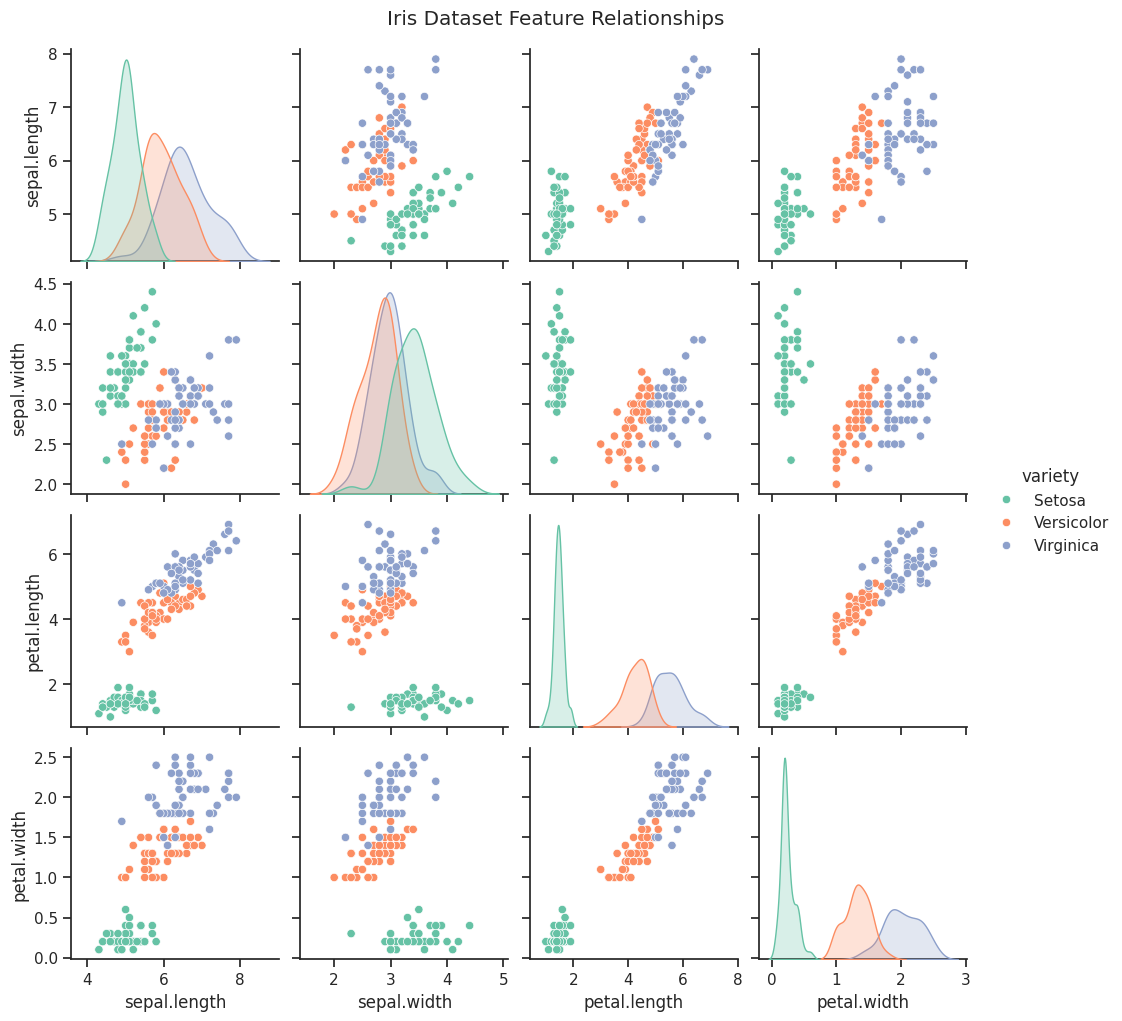

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for cleaner graphs
sns.set_theme(style="ticks")

# Plot all features colored by the 'variety' column
pair_plot = sns.pairplot(df, hue="variety", palette="Set2", diag_kind="kde")
pair_plot.fig.suptitle("Iris Dataset Feature Relationships", y=1.02)

plt.show()

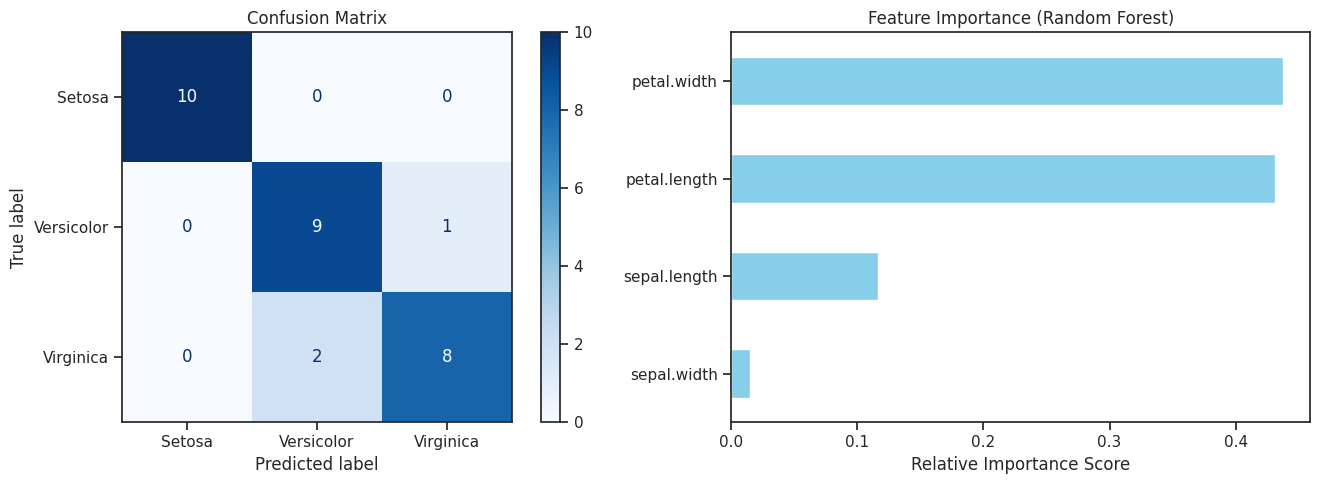

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", ax=ax[0], values_format='d')
ax[0].set_title("Confusion Matrix")
ax[0].grid(False) # Turn off grid lines for clean visual

# --- Plot 2: Feature Importance ---
# Get feature scores from your trained random forest model
importances = model.feature_importances_
feature_names = X.columns

# Sort features by importance
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Plot horizontal bar chart
feat_importances.plot(kind='barh', color='skyblue', ax=ax[1])
ax[1].set_title("Feature Importance (Random Forest)")
ax[1].set_xlabel("Relative Importance Score")

plt.tight_layout()
plt.show()

# Save the trained model

In [15]:
import joblib

# Save the trained Random Forest model
joblib.dump(model, 'iris_random_forest_model.pkl')

# Save the label encoder (crucial for decoding predictions later)
joblib.dump(label_encoder, 'iris_label_encoder.pkl')

print("Model and Label Encoder saved locally successfully!")

Model and Label Encoder saved locally successfully!


# Load saved model and test with our own data

In [17]:
import joblib
import pandas as pd

# Load kembali model dan encoder dari direktori Anda
loaded_model = joblib.load('iris_random_forest_model.pkl')
loaded_encoder = joblib.load('iris_label_encoder.pkl')

print("Model dan Label Encoder berhasil dimuat!")

Model dan Label Encoder berhasil dimuat!


In [23]:
data_baru = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], 
                         columns=['sepal.length', 'sepal.width', 'petal.length', 'petal.width'])

prediksi_angka = loaded_model.predict(data_baru)
prediksi_nama = loaded_encoder.inverse_transform(prediksi_angka)

print(f"Hasil prediksi untuk data baru: {prediksi_nama[0]}")

Hasil prediksi untuk data baru: Setosa
